In [1]:
# Zachary Katz
# zachary_katz@mines.edu
# 14 March 2026

"""
Overview Figure for David Glacier Subglacial Hydrology Radar Specularity Paper

Map of David Glacier [MOA, Velocity] with insets for radar lines, seismic, ICESat-2/CryoSat-2 outlines, and DDInSAR outlines.
"""

# Imports
import shapefile
import shapely
from pyproj import CRS, Transformer
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import geopandas as gpd
import cmasher as cmr
import xarray as xr
import rasterio
import numpy as np
from cmap import Colormap
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import os
import matplotlib.colors as colors
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# User-defined paths
offset_video_path_1617 = '../_Data/UTG_1617_OffsetVideo'
offset_video_path_1819 = '../_Data/UTG_1819_OffsetVideo'
vel_path = '/mnt/c/users/ZacharyKatz/Desktop/Research/Background/antarctica_ice_velocity_450m_v2.nc' # Path to velocity field
moa_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/moa750_2009_hp1_v1.1.tif' # Path to MOA
sld_path = '../_Data/Ju_SLD2'
seismic_path = '../_Data/Ju_Seismic/SeismicKSS2_21-22.csv'
evolving_path = '../_Data/Sauthoff_EvolvingOutlines'
DDInSAR_path = '../_Data/Kim_DDInSAR'
# RINGS Grounding Line Paths
rings_grounded_path = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp'
rings_coastline_path = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_coastline_2022.shp'
rings_grounded_path = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp'
rings_iceshelves_path = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_iceshelves_2022.shp'
rings_islands_ADD = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_islands_ADD.shp'
rings_polygonmask = '/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_polygonmask.shp'

# Functions
def ll2xy(lon: list[float], lat: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y).
    Can also take single floats.

    Parameters
    ----------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326

    Returns
    -------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y


In [2]:
# Load grounding lines
paths = [
    rings_coastline_path,
    rings_grounded_path,
    rings_iceshelves_path,
    rings_islands_ADD,
    rings_polygonmask,
]

records_full = []
shapes_full = []
field_names_full = []

for path in paths:
    sf = shapefile.Reader(path)
    records_full.append(sf.records())
    shapes_full.append(sf.shapes())
    field_names_full.append([f[0] for f in sf.fields[1:]])

ice_shelf_polygons = []
grounded_polygons = []

sf = shapefile.Reader(rings_iceshelves_path)
fields = sf.fields[1:]  # Skip deletion flag
field_names = [field[0] for field in fields]

records = sf.records()
shapes = sf.shapes()

for record, shape in zip(records, shapes):
    rec_dict = dict(zip(field_names, record))
    classification = rec_dict["Type"]
    points = shape.points
    parts = list(shape.parts)
    parts.append(len(points))  # Append the end index of the last part
    for i in range(len(parts) - 1):
        part = points[parts[i] : parts[i + 1]]
        polygon = shapely.Polygon(part)
        if (
            classification == "Isolated island"
            or classification == "Ice rise or connected island"
            or classification == "Grounded ice or land"
        ):
            if polygon.is_valid:
                grounded_polygons.append(polygon)
        elif classification == "Ice shelf":
            if polygon.is_valid:
                ice_shelf_polygons.append(polygon)
        else:
            print(f"Unknown classification: {classification}")

def plot_RINGS_shapefile(
    records_list: list[shapefile._Record],
    shapes_list: list[shapefile.Shape],
    field_names_list: list[str],
    ax ,
    colors: list[str],
    transform,
    fill: bool = False,
    zorder: int = 2,
    linewidth: int = 2,
) -> None:
    """
    Plots the given records and shapes on axis ax.

    Example usage:
    
    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=inset, colors=['lightgray','white'],
        transform=ps71_projection, fill=True, zorder=2, linewidth=1)

    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['white','None'],
        transform=ps71_projection, fill=False, zorder=2, linewidth=1)

    Parameters
    ----------
    records : list[shapefile._Record]
        Shapely record containing shape classification
    shapes : list[shapefile.Shape]
        Shapely shape points
    ax : cartopy.mpl.geoaxes.GeoAxes
        Axes to polot on
    colors : list[str]
       [Grounded ice color, Ice Shelf color]; Must be length 2
    """
    for records, shapes, field_names in zip(records_list, shapes_list, field_names_list):
        for record, shape in zip(records, shapes):
            rec_dict = dict(zip(field_names, record))
            classification = rec_dict["Type"]
            points = shape.points
            parts = list(shape.parts)
            parts.append(len(points)) # Append the end index of the last part of the shapefile
            for i in range(len(parts) - 1):
                    part = points[parts[i] : parts[i + 1]]
                    if classification == "Coastline":
                        if fill:
                            ax.fill(*zip(*part), color=colors[1], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[1], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Grounded":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Transient":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Island":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    else:
                        #print(f"Unknown classification: {classification}")
                        continue

In [3]:
# Load Lake Cheongsuk shapefile
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)

# Load seismic data
seismic = pd.read_csv(seismic_path)

# Load evolving outlines
evolving_outlines = gpd.read_file(f'{evolving_path}/David_s1.geojson')

# Load DDInSAR outlines
path2 = f'{DDInSAR_path}/David2.shp'
path2_1 = f'{DDInSAR_path}/David2-1.shp'

DDInSAR_outlines = []
for path in [path2, path2_1]:
    sf = shapefile.Reader(path)
    for shape in sf.shapes():
        points = shape.points
        pts_xy = ll2xy([p[0] for p in points], [p[1] for p in points])
        x, y = pts_xy

        DDInSAR_outlines.append((x, y))

# Load radar lines
file_paths_1819 = [os.path.join(offset_video_path_1819, f) for f in os.listdir(offset_video_path_1819) if f.endswith('.nc')]
file_paths_1617 = [os.path.join(offset_video_path_1617, f) for f in os.listdir(offset_video_path_1617) if f.endswith('.nc')]

offset_video_radargrams_1819 = []
for f in file_paths_1819:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1819.append(offset_video_radargram)

offset_video_radargrams_1819.sort(key=lambda x: x.transect_id)

offset_video_radargrams_1617 = []
for f in file_paths_1617:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1617.append(offset_video_radargram)

offset_video_radargrams_1617.sort(key=lambda x: x.transect_id)


In [4]:
# Load velocity
bbox = [350000,-1605000,800000,-1320000] #David_SGL2_full
off = 10000

vel = xr.open_dataset(vel_path)
cropped_vel = vel.sel(x=slice(bbox[0]-off,bbox[2]+ off),y=slice(bbox[3] + off,bbox[1]   - off))
vel_mag_sliced = np.sqrt(cropped_vel.VX**2 + cropped_vel.VY**2)

oslo = Colormap('crameri:oslo').to_matplotlib()
oslo = cmr.get_sub_cmap(oslo, 0.3, 1.0)
oslo = oslo.copy()        
oslo.set_over(oslo(1.0))

# Load Mosaic of Antarctica
with rasterio.open(moa_path) as moa:
    bounds = moa.bounds
    left, bottom, right, top = bounds.left, bounds.bottom, bounds.right, bounds.top
    moa_dat = moa.read(1)

ext = (left, right, bottom, top)

In [5]:
# Evolving outline mids
times = evolving_outlines["mid_pt_datetime"]
# Find index of time closest to Jan 25 2017 and Nov 20 2018
target_time_1617 = np.datetime64('2017-01-25T00:00:00')
target_time_1819 = np.datetime64('2018-11-20T00:00:00')

idx_1617 = np.argmin(np.abs(times - target_time_1617))
idx_1819 = np.argmin(np.abs(times - target_time_1819))
print(times[idx_1617], times[idx_1819])
t_num = np.array(times.astype("int64"))  # nanoseconds since epoch


# Normalize to 0–1 range for the colormap
norm = colors.Normalize(vmin=t_num.min(), vmax=t_num.max())
cmap = cm.get_cmap("inferno")
sm = cm.ScalarMappable(norm=norm, cmap=cmap)


2017-01-01 00:00:00 2019-01-01 00:00:00


/tmp/ipykernel_3516/2328438209.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("inferno")


In [6]:
# Plotting choices

Jan_1_17_Evolving_Outline = True
Jan_1_19_Evolving_Outline = False

radar_lines = False
radar_outline = False
DDInSAR_outline = False


AX1
AX2


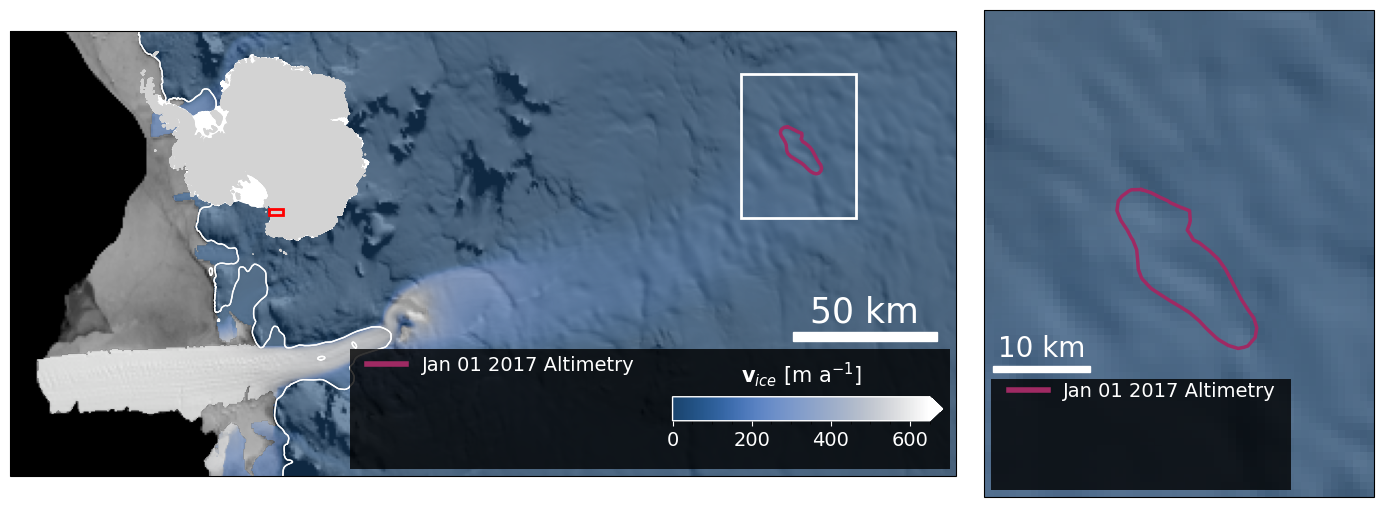

In [7]:
# COG 2 Panel Map
lake_color = 'white'
#[#56ebd3, #f15d82, #a5e841]
_1617color = "#a5e841"
_1819color = '#f15d82'
_seiscolor = '#56ebd3'
bbox = [390000,-1565000,720000,-1410000] #David_SGL2_full
bbox_zoom = [645000,-1475000,685000,-1425000] #David_SGL2
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig = plt.figure(figsize=(17.6, 8))

gs = gridspec.GridSpec(1, 10)
# Top panel spanning all columns
ax1 = fig.add_subplot(gs[0, :7],projection=ps71_projection)
# Bottom three panels
ax2 = fig.add_subplot(gs[0, 7:],projection=ps71_projection)
ax1.set_xlim(bbox[0],bbox[2])
ax1.set_ylim(bbox[1],bbox[3])
ax2.set_xlim(bbox_zoom[0],bbox_zoom[2])
ax2.set_ylim(bbox_zoom[1],bbox_zoom[3])


print("AX1")
handles = []
# Mask moa_dat to vel_mag not nan
ax1.imshow(moa_dat, extent=ext, cmap="gray", vmin=12000, vmax=19000)

cb = ax1.imshow(vel_mag_sliced, cmap=oslo,extent=[vel_mag_sliced['x'].min(), vel_mag_sliced['x'].max(),
     vel_mag_sliced['y'].min(), vel_mag_sliced['y'].max()],origin='upper',vmin=0,vmax=650)

if Jan_1_17_Evolving_Outline and Jan_1_19_Evolving_Outline:
    colors = []
    indices = [idx_1617, idx_1819]
    for index in indices:
        outline = evolving_outlines['geometry'][index]
        time = t_num[index]
        color = cmap(norm(time))
        x_evolve, y_evolve = outline.exterior.xy
        ax1.plot(x_evolve, y_evolve, color=color, zorder=5, linewidth=2.5)
        colors.append(color)

    handles.append(Line2D([0], [0], color=colors[0], lw=4, label='Jan 01 2017 Altimetry'))
    handles.append(Line2D([0], [0], color=colors[1], lw=4, label='Jan 01 2019 Altimetry'))

elif Jan_1_17_Evolving_Outline:
    colors = []
    indices = [idx_1617]
    for index in indices:
        outline = evolving_outlines['geometry'][index]
        time = t_num[index]
        color = cmap(norm(time))
        x_evolve, y_evolve = outline.exterior.xy
        ax1.plot(x_evolve, y_evolve, color=color, zorder=5, linewidth=2.5)
        colors.append(color)

    handles.append(Line2D([0], [0], color=colors[0], lw=4, label='Jan 01 2017 Altimetry'))
    handles.append(Line2D([], [], color='red', lw=0, label=''))


elif Jan_1_19_Evolving_Outline:
    colors = []
    indices = [idx_1819]
    for index in indices:
        outline = evolving_outlines['geometry'][index]
        time = t_num[index]
        color = cmap(norm(time))
        x_evolve, y_evolve = outline.exterior.xy
        ax1.plot(x_evolve, y_evolve, color=color, zorder=5, linewidth=2.5)
        colors.append(color)

    handles.append(Line2D([0], [0], color=colors[0], lw=4, label='Jan 01 2019 Altimetry'))
    handles.append(Line2D([], [], color='red', lw=0, label=''))

if DDInSAR_outline:
    for outline in DDInSAR_outlines:
        x_DDInSAR, y_DDInSAR = outline
        ax1.plot(x_DDInSAR, y_DDInSAR, color='gold', linewidth=2, zorder=3, transform=ps71_projection)
    handles.append(Line2D([0], [0], color='gold', lw=4, label='2022–2017 DDInSAR'))
else:
    handles.append(Line2D([], [], color='red', lw=0, label=''))

if radar_outline:
    ax1.plot(xs[0], ys[0], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    ax1.plot(xs[1], ys[1], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    ax1.plot(xs[2], ys[2], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    handles.append(Line2D([0], [0], color=lake_color, lw=4, label='November 2018 Radar'))
else:
    handles.append(Line2D([], [], color='red', lw=0, label=''))

    # Legend and Colorbar
k_cbar_anchor = (1,0) # Bottom right of ax1
cbbox = inset_axes(ax1, width=6,height=1.2,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax1.transAxes, loc="lower right")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.8])
cbaxes = inset_axes(cbbox, '45%', '20%', loc = 'right')
cbar = fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
cb.set_alpha(0.6)

cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label(r"$\mathbf{v}_{ice}$ [m a$^{-1}$]", fontsize=15, color='white', labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.minorticks_on()



# Add legend directly to cbbox
legend = cbbox.legend(
    handles=handles,
    loc='center left',          # center vertically, left horizontally
    bbox_to_anchor=(0.0, 0.5), # tweak horizontal position
    frameon=False,
    fontsize=14,
    labelcolor='white'
)

# Make sure text is white
for text in legend.get_texts():
    text.set_color('white')

plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax1, colors=['white','None'],
       transform=ps71_projection, fill=False, zorder=2, linewidth=1)

rect = plt.Rectangle(
    (
        bbox_zoom[0],
        bbox_zoom[1],
    ),
    bbox_zoom[2] - bbox_zoom[0],
    bbox_zoom[3] - bbox_zoom[1],
    zorder=3,
    linewidth=2,
    edgecolor="white",
    facecolor="none",
)
ax1.add_patch(rect)

scalebar = AnchoredSizeBar(ax1.transData,
                        50000, '50 km', 'lower right', 
                        pad=0.2,
                        sep=2,
                        color='white',
                        frameon=False,
                        size_vertical=3000,
                        fontproperties=mpl.font_manager.FontProperties(size=25),
                        label_top=True)


ax1.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, 0.28), transform=ax1.transAxes)

# Add inset map
fig_width, fig_height = fig.get_size_inches()
inset_width_frac = 4 / fig_width
inset_height_frac = 4 / fig_height
bbox_1= ax1.get_position()
# Top-left position of inset
location = [
    bbox_1.x0, 
    bbox_1.y0 + bbox_1.height * 1/2 * 0.95, 
    bbox_1.height * 1/2, 
    bbox_1.height * 1/2
]

inset = fig.add_axes(location, projection=ps71_projection)
inset.patch.set_facecolor("none")
for spine in inset.spines.values():
    spine.set_visible(False)
inset.set_xticks([])
inset.set_yticks([])

#Plot map of Antarctica
plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=inset, colors=['lightgray','white'],
        transform=ps71_projection, fill=True, zorder=2, linewidth=1)

rect = plt.Rectangle(
    (
        bbox[0],
        bbox[1],
    ),
    bbox[2] - bbox[0],
    bbox[3] - bbox[1],
    zorder=3,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
inset.add_patch(rect)



#####################################
#####################################
#####################################
handles = []
print("AX2")
ax2.imshow(moa_dat, extent=ext, cmap="gray", vmin=12000, vmax=19000)
ax2.imshow(vel_mag_sliced, cmap=oslo,extent=[vel_mag_sliced['x'].min(), vel_mag_sliced['x'].max(),
     vel_mag_sliced['y'].min(), vel_mag_sliced['y'].max()],origin='upper',vmin=0,vmax=650,alpha=0.6)
if Jan_1_17_Evolving_Outline and Jan_1_19_Evolving_Outline:
    colors = []
    indices = [idx_1617, idx_1819]
    for index in indices:
        outline = evolving_outlines['geometry'][index]
        time = t_num[index]
        color = cmap(norm(time))
        x_evolve, y_evolve = outline.exterior.xy
        ax2.plot(x_evolve, y_evolve, color=color, zorder=5, linewidth=2.5)
        colors.append(color)

    handles.append(Line2D([0], [0], color=colors[0], lw=4, label='Jan 01 2017 Altimetry'))
    handles.append(Line2D([0], [0], color=colors[1], lw=4, label='Jan 01 2019 Altimetry'))

elif Jan_1_17_Evolving_Outline:
    colors = []
    indices = [idx_1617]
    for index in indices:
        outline = evolving_outlines['geometry'][index]
        time = t_num[index]
        color = cmap(norm(time))
        x_evolve, y_evolve = outline.exterior.xy
        ax2.plot(x_evolve, y_evolve, color=color, zorder=5, linewidth=2.5)
        colors.append(color)

    handles.append(Line2D([0], [0], color=colors[0], lw=4, label='Jan 01 2017 Altimetry'))
    handles.append(Line2D([], [], color='red', lw=0, label=''))


elif Jan_1_19_Evolving_Outline:
    colors = []
    indices = [idx_1819]
    for index in indices:
        outline = evolving_outlines['geometry'][index]
        time = t_num[index]
        color = cmap(norm(time))
        x_evolve, y_evolve = outline.exterior.xy
        ax2.plot(x_evolve, y_evolve, color=color, zorder=5, linewidth=2.5)
        colors.append(color)

    handles.append(Line2D([0], [0], color=colors[0], lw=4, label='Jan 01 2019 Altimetry'))
    handles.append(Line2D([], [], color='red', lw=0, label=''))

if DDInSAR_outline:
    for outline in DDInSAR_outlines:
        x_DDInSAR, y_DDInSAR = outline
        ax2.plot(x_DDInSAR, y_DDInSAR, color='gold', linewidth=2, zorder=3, transform=ps71_projection)
    handles.append(Line2D([0], [0], color='gold', lw=4, label='2022–2017 DDInSAR'))
else:
    handles.append(Line2D([], [], color='red', lw=0, label=''))

if radar_outline:
    ax2.plot(xs[0], ys[0], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    ax2.plot(xs[1], ys[1], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    ax2.plot(xs[2], ys[2], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    handles.append(Line2D([0], [0], color=lake_color, lw=4, label='November 2018 Radar'))
else:
    handles.append(Line2D([], [], color='red', lw=0, label=''))

scalebar = AnchoredSizeBar(ax2.transData,
                        10000, '10 km', 'lower left', 
                        pad=0.2,
                        sep=2,
                        color='white',
                        frameon=False,
                        size_vertical=600,
                        fontproperties=mpl.font_manager.FontProperties(size=20),
                        label_top=True)


ax2.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.0, 0.24), transform=ax2.transAxes)

k_cbar_anchor = (0,0) # Bottom right of ax1
cbbox = inset_axes(ax2, width=3,height=1.11,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax2.transAxes, loc="lower left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.8])


# Add legend directly to cbbox
legend = cbbox.legend(
    handles=handles,
    loc='center left',          # center vertically, left horizontally
    bbox_to_anchor=(0.0, 0.5), # tweak horizontal position
    frameon=False,
    fontsize=14,
    labelcolor='white'
)

# Make sure text is white
for text in legend.get_texts():
    text.set_color('white')

gs.update(wspace=0.25, hspace=0.02)

fig.savefig('./Figure1_COG.png', dpi=300, bbox_inches='tight')

In [ ]:
# COG 2 Panel Map
radar_outline = True
lake_color = 'white'
#[#56ebd3, #f15d82, #a5e841]
_1617color = "#a5e841"
_1819color = '#f15d82'
_seiscolor = '#56ebd3'
bbox = [390000,-1565000,720000,-1410000] #David_SGL2_full
bbox_zoom = [645000,-1475000,685000,-1425000] #David_SGL2
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig = plt.figure(figsize=(17.6, 8))

gs = gridspec.GridSpec(1, 10)
# Top panel spanning all columns
ax1 = fig.add_subplot(gs[0, :7],projection=ps71_projection)
# Bottom three panels
ax2 = fig.add_subplot(gs[0, 7:],projection=ps71_projection)
ax1.set_xlim(bbox[0],bbox[2])
ax1.set_ylim(bbox[1],bbox[3])
ax2.set_xlim(bbox_zoom[0],bbox_zoom[2])
ax2.set_ylim(bbox_zoom[1],bbox_zoom[3])


print("AX1")
handles = []
# Mask moa_dat to vel_mag not nan
ax1.imshow(moa_dat, extent=ext, cmap="gray", vmin=12000, vmax=19000)

cb = ax1.imshow(vel_mag_sliced, cmap=oslo,extent=[vel_mag_sliced['x'].min(), vel_mag_sliced['x'].max(),
     vel_mag_sliced['y'].min(), vel_mag_sliced['y'].max()],origin='upper',vmin=0,vmax=650)


handles.append(Line2D([], [], color='red', lw=0, label=''))

for radargram in offset_video_radargrams_1819:
    ax1.plot(radargram.x, radargram.y, color=_1819color, linewidth=1, zorder=3, transform=ps71_projection)
for radargram in offset_video_radargrams_1617:
    ax1.plot(radargram.x, radargram.y, color=_1617color, linewidth=1, zorder=3, transform=ps71_projection)

handles.append(Line2D([0], [0], color=_1617color, lw=4, label='January 2017 Radar'))
handles.append(Line2D([0], [0], color=_1819color, lw=4, label='November 2018 Radar'))

if radar_outline:
    ax2.plot(xs[0], ys[0], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    ax2.plot(xs[1], ys[1], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    ax2.plot(xs[2], ys[2], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    handles.append(Line2D([0], [0], color=lake_color, lw=4, label='November 2018 Radar'))
else:
    handles.append(Line2D([], [], color='red', lw=0, label=''))

    # Legend and Colorbar
k_cbar_anchor = (1,0) # Bottom right of ax1
cbbox = inset_axes(ax1, width=6,height=1.2,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax1.transAxes, loc="lower right")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.8])
cbaxes = inset_axes(cbbox, '45%', '20%', loc = 'right')
cbar = fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
cb.set_alpha(0.6)

cbar.outline.set_edgecolor('white')
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
cbar.set_label(r"$\mathbf{v}_{ice}$ [m a$^{-1}$]", fontsize=15, color='white', labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.minorticks_on()



# Add legend directly to cbbox
legend = cbbox.legend(
    handles=handles,
    loc='center left',          # center vertically, left horizontally
    bbox_to_anchor=(0.0, 0.5), # tweak horizontal position
    frameon=False,
    fontsize=14,
    labelcolor='white'
)

# Make sure text is white
for text in legend.get_texts():
    text.set_color('white')

#plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax1, colors=['white','None'],
#       transform=ps71_projection, fill=False, zorder=2, linewidth=1)

rect = plt.Rectangle(
    (
        bbox_zoom[0],
        bbox_zoom[1],
    ),
    bbox_zoom[2] - bbox_zoom[0],
    bbox_zoom[3] - bbox_zoom[1],
    zorder=3,
    linewidth=2,
    edgecolor="white",
    facecolor="none",
)
ax1.add_patch(rect)

scalebar = AnchoredSizeBar(ax1.transData,
                        50000, '50 km', 'lower right', 
                        pad=0.2,
                        sep=2,
                        color='white',
                        frameon=False,
                        size_vertical=3000,
                        fontproperties=mpl.font_manager.FontProperties(size=25),
                        label_top=True)


ax1.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.99, 0.28), transform=ax1.transAxes)

# Add inset map
fig_width, fig_height = fig.get_size_inches()
inset_width_frac = 4 / fig_width
inset_height_frac = 4 / fig_height
bbox_1= ax1.get_position()
# Top-left position of inset
location = [
    bbox_1.x0, 
    bbox_1.y0 + bbox_1.height * 1/2 * 0.95, 
    bbox_1.height * 1/2, 
    bbox_1.height * 1/2
]

inset = fig.add_axes(location, projection=ps71_projection)
inset.patch.set_facecolor("none")
for spine in inset.spines.values():
    spine.set_visible(False)
inset.set_xticks([])
inset.set_yticks([])

#Plot map of Antarctica
#plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=inset, colors=['lightgray','white'],
#        transform=ps71_projection, fill=True, zorder=2, linewidth=1)

rect = plt.Rectangle(
    (
        bbox[0],
        bbox[1],
    ),
    bbox[2] - bbox[0],
    bbox[3] - bbox[1],
    zorder=3,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
inset.add_patch(rect)

# Add velocity arrows
cropped_vel.thin(34).plot.quiver(
    "x", "y", "VX", "VY", alpha=0.5, color="white", ax=ax1, scale=4500, width=0.004
)


#####################################
#####################################
#####################################
handles = []
print("AX2")
ax2.imshow(moa_dat, extent=ext, cmap="gray", vmin=12000, vmax=19000)
ax2.imshow(vel_mag_sliced, cmap=oslo,extent=[vel_mag_sliced['x'].min(), vel_mag_sliced['x'].max(),
     vel_mag_sliced['y'].min(), vel_mag_sliced['y'].max()],origin='upper',vmin=0,vmax=650,alpha=0.6)



handles.append(Line2D([], [], color='red', lw=0, label=''))

for radargram in offset_video_radargrams_1819:
    ax2.plot(radargram.x, radargram.y, color=_1819color, linewidth=1, zorder=3, transform=ps71_projection)
for radargram in offset_video_radargrams_1617:
    ax2.plot(radargram.x, radargram.y, color=_1617color, linewidth=1, zorder=3, transform=ps71_projection)

handles.append(Line2D([0], [0], color=_1617color, lw=4, label='January 2017 Radar'))
handles.append(Line2D([0], [0], color=_1819color, lw=4, label='November 2018 Radar'))


if radar_outline:
    ax2.plot(xs[0], ys[0], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    ax2.plot(xs[1], ys[1], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    ax2.plot(xs[2], ys[2], color=lake_color, linewidth=2, zorder=3, transform=ps71_projection)
    handles.append(Line2D([0], [0], color=lake_color, lw=4, label='November 2018 Radar'))
else:
    handles.append(Line2D([], [], color='red', lw=0, label=''))

scalebar = AnchoredSizeBar(ax2.transData,
                        10000, '10 km', 'lower left', 
                        pad=0.2,
                        sep=2,
                        color='white',
                        frameon=False,
                        size_vertical=600,
                        fontproperties=mpl.font_manager.FontProperties(size=20),
                        label_top=True)


ax2.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.0, 0.24), transform=ax2.transAxes)

k_cbar_anchor = (0,0) # Bottom right of ax1
cbbox = inset_axes(ax2, width=3,height=1.11,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax2.transAxes, loc="lower left")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.8])


# Add legend directly to cbbox
legend = cbbox.legend(
    handles=handles,
    loc='center left',          # center vertically, left horizontally
    bbox_to_anchor=(0.0, 0.5), # tweak horizontal position
    frameon=False,
    fontsize=14,
    labelcolor='white'
)

# Make sure text is white
for text in legend.get_texts():
    text.set_color('white')

cropped_vel.thin(20).plot.quiver(
    "x", "y", "VX", "VY", alpha=0.5, color="white", ax=ax2, scale=600, width=0.008
)


gs.update(wspace=0.25, hspace=0.02)

fig.savefig('./Figure1_COG.png', dpi=300, bbox_inches='tight')

AX1


/home/zkatz/Research/DavidSpecularity/.venv/lib/python3.12/site-packages/xarray/plot/accessor.py:1160: FutureWarning: Using positional arguments is deprecated for plot methods, use keyword arguments instead.
  return dataset_plot.quiver(self._ds, *args, **kwargs)


AX2


/home/zkatz/Research/DavidSpecularity/.venv/lib/python3.12/site-packages/xarray/plot/accessor.py:1160: FutureWarning: Using positional arguments is deprecated for plot methods, use keyword arguments instead.
  return dataset_plot.quiver(self._ds, *args, **kwargs)
